# Sparse-view depth-prior 3DGS — Colab runner

This notebook runs the study on a Colab GPU. It installs and compiles the
rasterizer, prepares NeRF-Synthetic, its reference depth and DTU, trains the runs
defined in `configs/sweep.yaml` one stage at a time, and turns the finished runs
into `results.csv`, the reproduction and divergence checks, and the analysis figures.

Colab clears `/content` at the end of every session, so the notebook keeps two
kinds of state apart. What is cheap to rebuild — the code, the installed
packages, the scenes copied to local disk — lives in `/content` and is rebuilt
in each session by cells 1–6. What costs GPU time — the compiled gsplat kernels,
the reference depth and every finished run — is stored on Google Drive, so a new
session continues from where the last one stopped.

| cell | what it does | time: first session / later sessions |
|---|---|---|
| 1 | reports the GPU and the PyTorch/CUDA build | seconds |
| 2 | mounts Drive and defines the data, run and mirror paths | seconds |
| 3 | copies the code, installs dependencies, compiles gsplat's CUDA kernels | ~10 min / ~1 min |
| 4 | copies the NeRF-Synthetic scenes to local disk | ~1 min per scene |
| 5 | builds the reference depth, or restores it from Drive | ~15 min per scene / seconds |
| 6 | shows three input views, their reference depth and the SfM point count | seconds |
| 7 | converts the DTU SampleSet (DTU stages only) | ~4 min |
| 8 | trains one stage of the sweep | ~1.5–2 min per run |
| 9 | collects all runs into `results.csv` and reports the reproduction and divergence checks | seconds |
| 10 | draws the analysis figures and saves them to Drive | seconds |

**Where things are stored**
```
MyDrive/datasets/nerf_synthetic/nerf_synthetic/<scene>/   NeRF-Synthetic, extracted
MyDrive/datasets/DTU/SampleSet.zip                          DTU official SampleSet
MyDrive/dl3dcv/final_project/                               the code (CODE_SOURCE='drive')
--- written by this notebook ---
MyDrive/dl3dcv/torch_extensions/<GPU>/                      compiled gsplat kernels
MyDrive/datasets/nerf_synthetic_depth/<scene>_depth.zip     reference depth
MyDrive/dl3dcv/runs/<stage>/<run_id>/                       every run: config, metrics, renders
MyDrive/dl3dcv/results.csv, figures/                        collected results and figures
```

## Which GPU to use

The rasterizer, gsplat, runs only on NVIDIA GPUs through CUDA. The runs are
small — 400×400 images (400×300 on DTU) and at most about 900k Gaussians — so
GPU memory is not the limit on any GPU Colab offers. What differs between them is
speed, compute-unit cost, and whether a stage finishes within one session.

| runtime | used in this study | suitability |
|---|---|---|
| **L4** (24 GB) | yes | **The best fit.** A stage of 20–48 runs finishes within one session, at a lower hourly cost than an A100. |
| **A100** (40 GB) | yes | **The fastest.** Worth it to finish a large stage in one sitting, though its compute-unit cost per hour rises faster than its speed advantage over an L4. |
| **T4** (16 GB) | no | **Only for short checks** such as the `smoke` stage. It has the memory, but it is the slowest (an estimated 3–4× slower than an A100), so a full stage risks outlasting the session. |
| **CPU or TPU** | no | **Not usable.** gsplat needs CUDA; cell 1 reports the missing GPU and cell 3 skips the install. |

gsplat compiles its CUDA kernels once per GPU type, which takes about 4–5
minutes, and cell 3 caches the build on Drive. This study built them for the L4
and the A100, so a session on either reaches training in a few minutes, while any
other GPU type pays the compile once.

### 1 · GPU check
Prints the GPU model, its memory and driver version, and the PyTorch/CUDA build,
and states whether PyTorch can see a GPU at all.

In [ ]:
#@title 1. What GPU did we get?
!nvidia-smi --query-gpu=name,memory.total,driver_version --format=csv
import torch
print('torch', torch.__version__, '| cuda', torch.version.cuda,
      '| available:', torch.cuda.is_available())
if not torch.cuda.is_available():
    print('\nNO GPU. Runtime > Change runtime type > GPU, then restart from cell 1.')

/bin/bash: line 1: nvidia-smi: command not found
torch 2.11.0+cpu | cuda None | available: False

NO GPU. Runtime > Change runtime type > GPU, then restart from cell 1.


### 2 · Drive and paths
Mounts Google Drive and defines where everything lives: `DATA_ROOT` and
`RUNS_ROOT` on the session's fast local disk, and `RUNS_MIRROR` on Drive, where
each run is copied as soon as it ends. It creates these folders and reports
whether the NeRF-Synthetic folder and the DTU SampleSet were found on Drive.

In [ ]:
#@title 2. Mount Drive and set paths
# Drive holds the datasets and receives every result, so it is required.
# If mount() fails with a 400 (common from the VS Code extension, or with
# several Google accounts signed in): open the notebook in the browser at
# colab.research.google.com, or sign out of the other accounts, then retry.
import os
from google.colab import drive
drive.mount('/content/drive')

DATASETS = '/content/drive/MyDrive/datasets'  #@param {type:'string'}
PROJECT  = '/content/drive/MyDrive/dl3dcv'    #@param {type:'string'}
DEPTH_STORE = f'{DATASETS}/nerf_synthetic_depth'

os.environ['DATA_ROOT']   = '/content/data'          # local disk: fast, per-session
os.environ['RUNS_ROOT']   = '/content/runs'          # where runs are written
os.environ['RUNS_MIRROR'] = f'{PROJECT}/runs'        # ...and copied the moment they end
for d in (PROJECT, os.environ['RUNS_MIRROR'], DEPTH_STORE, '/content/data', '/content/runs'):
    os.makedirs(d, exist_ok=True)

for label, path in (('NeRF-Synthetic', f'{DATASETS}/nerf_synthetic'),
                    ('DTU SampleSet ', f'{DATASETS}/DTU/SampleSet.zip')):
    print(f'{label} {"found  " if os.path.exists(path) else "MISSING"} {path}')
print('runs mirror   ', os.environ['RUNS_MIRROR'])

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
NeRF-Synthetic found   /content/drive/MyDrive/datasets/nerf_synthetic
DTU SampleSet  found   /content/drive/MyDrive/datasets/DTU/SampleSet.zip
runs mirror    /content/drive/MyDrive/dl3dcv/runs


### 3 · Code and installation
Copies the project from `MyDrive/dl3dcv/final_project` (or clones it from GitHub)
to local disk, and drops any `src` modules imported from an earlier copy, so a
re-run always uses the current code. It then runs `scripts/setup_gpu.sh`, which
installs the GPU dependencies, renders one test Gaussian so that gsplat compiles
its CUDA kernels here rather than inside the first training run, and runs the
test suite. The compiled kernels are cached on Drive, one build per GPU type.

In [ ]:
#@title 3. Get the code and install
# 'drive' : copy the project from MyDrive/dl3dcv/final_project (put it there
#           with Google Drive for Desktop -- no GitHub needed)
# 'github': clone GITHUB_REPO (must be public, or add a token to the URL)
CODE_SOURCE = 'drive'  #@param ['drive', 'github']
GITHUB_REPO = 'https://github.com/AMEER7525/depth-prior-tax.git'  #@param {type:'string'}
REPO_DIR = '/content/final_project'

import os, subprocess, sys, torch
if CODE_SOURCE == 'drive':
    src = f'{PROJECT}/final_project'
    if not os.path.exists(f'{src}/src/data.py'):
        raise SystemExit(f'no code at {src}. Copy the project folder there, or use github.')
    subprocess.run(['rsync', '-a', '--delete', '--exclude', '.git', '--exclude', '.venv',
                    '--exclude', 'runs', '--exclude', 'data', '--exclude', '__pycache__',
                    f'{src}/', f'{REPO_DIR}/'], check=True)
elif not os.path.isdir(f'{REPO_DIR}/.git'):
    subprocess.run(['git', 'clone', GITHUB_REPO, REPO_DIR], check=False)
else:
    subprocess.run(['git', '-C', REPO_DIR, 'pull', '--ff-only'], check=False)

missing = [f for f in ('src/data.py', 'scripts/train.py', 'configs/sweep.yaml')
           if not os.path.exists(f'{REPO_DIR}/{f}')]
if missing:
    raise SystemExit(f'code incomplete, missing {missing} -- check CODE_SOURCE / GITHUB_REPO')
os.chdir(REPO_DIR)
sys.path.insert(0, REPO_DIR)
# Re-running this cell must be enough to pick up edited code: drop the
# modules imported from the previous copy, or `from src import ...` in later
# cells keeps handing back the old ones until the runtime restarts.
for m in [m for m in sys.modules if m == 'src' or m.startswith('src.')]:
    del sys.modules[m]
print('code OK at', REPO_DIR)

# gsplat JIT-compiles its CUDA kernels on first import (minutes). Keep the
# build on Drive, keyed by GPU and torch, so later sessions reuse it.
if torch.cuda.is_available():
    tag = (torch.cuda.get_device_name(0).replace(' ', '_') + '_torch'
           + torch.__version__.split('+')[0] + '_cu' + str(torch.version.cuda))
    os.environ['TORCH_EXTENSIONS_DIR'] = f'{PROJECT}/torch_extensions/{tag}'
    !bash scripts/setup_gpu.sh
else:
    print('No GPU: skipping gsplat install. Cells 4-6 still work.')

code OK at /content/final_project
No GPU: skipping gsplat install. Cells 4-6 still work.


### 4 · NeRF-Synthetic on local disk
Copies the scenes in `SCENES` (lego, chair and ship; all eight when
`ALL_8_FOR_STAGE0` is set, for the reproduction stage) from Drive to local disk,
without the normal maps. Training reads thousands of small PNGs, which is slow
and rate-limited over the Drive mount. A scene with no extracted copy on Drive is
downloaded instead.

In [ ]:
#@title 4. Copy NeRF-Synthetic scenes to local disk
# Training must read local disk, never the Drive FUSE mount: thousands of
# small PNGs over FUSE are slow and rate-limited.
SCENES = 'lego chair ship'  #@param {type:'string'}
ALL_8_FOR_STAGE0 = False    #@param {type:'boolean'}
import glob, os, shutil, subprocess
ALL = ['chair', 'drums', 'ficus', 'hotdog', 'lego', 'materials', 'mic', 'ship']
scenes = ALL if ALL_8_FOR_STAGE0 else SCENES.split()
DATA = os.environ['DATA_ROOT']

root = next((c for pat in ('nerf_synthetic/nerf_synthetic', 'nerf_synthetic', '*/nerf_synthetic')
             for c in glob.glob(f'{DATASETS}/{pat}') if os.path.isdir(f'{c}/lego')), None)
for s in scenes:
    dst = f'{DATA}/nerf_synthetic/{s}'
    if os.path.exists(f'{dst}/transforms_test.json'):
        print(f'  have    {s}'); continue
    if root:
        print(f'  copying {s} ...', end=' ', flush=True)
        shutil.copytree(f'{root}/{s}', dst, dirs_exist_ok=True,
                        ignore=shutil.ignore_patterns('*_normal_*'))
        print(len(glob.glob(f'{dst}/**/*.png', recursive=True)), 'png')
    else:
        print('  no extracted copy on Drive; downloading', s)
        subprocess.run(['python', 'scripts/fetch_data.py', '--scenes', s,
                        '--archives', '/content/archives', '--extract', DATA], check=False)
print('\nDATA_ROOT =', DATA)

  copying lego ... 

KeyboardInterrupt: 

### 5 · Reference depth
NeRF-Synthetic ships no metric depth, so this cell provides the depth that every
depth prior in the study is derived from. `scripts/make_gt_depth.py` fits 3DGS to
all 400 views of a scene at 800×800, with the alpha masks as extra supervision,
and renders its depth at every train and test pose — about 15 minutes per scene.
The result is zipped to `datasets/nerf_synthetic_depth/`, so later sessions
restore it in seconds. The printed line summarizes the fit: held-out PSNR,
multi-view consistency, and rank correlation with the release's 8-bit depth PNGs.

Those are self-consistency checks. The reference's accuracy was measured
separately, against exact depth rendered from the original Blender scenes
(`scripts/render_blender_depth.py`, `scripts/validate_reference_depth.py`):
0.22–0.38% AbsRel on lego and chair and 2.3% on ship
(`results/reference_validation.json`).

In [ ]:
#@title 5. Reference depth (restored from Drive when already built)
REF_ITERS = 30000  #@param {type:'integer'}
import json, os
need = ' '.join(s for s in SCENES.split())
!python scripts/make_gt_depth.py --scene {need} --iterations {REF_ITERS} --persist "{DEPTH_STORE}"
for s in SCENES.split():
    p = f"{os.environ['DATA_ROOT']}/nerf_synthetic/{s}/depth_reference.json"
    if os.path.exists(p):
        r = json.load(open(p))
        print(f"{s:6s} fit PSNR {r.get('fit_psnr_test', float('nan')):.2f} | multi-view median "
              f"rel. error {r.get('mv_median_rel_err')} | within 1%: {r.get('mv_within_1pct')} "
              f"| rank corr. with release PNGs {r.get('png_spearman')}")

[lego] fitting the reference on 400 views (30000 iterations)
( ●    ) gsplat: Setting up CUDA with MAX_JOBS=10 (This may take a few minutes 
(  ●   ) gsplat: Setting up CUDA with MAX_JOBS=10 (This may take a few minutes 
(   ●  ) gsplat: Setting up CUDA with MAX_JOBS=10 (This may take a few minutes 
(    ● ) gsplat: Setting up CUDA with MAX_JOBS=10 (This may take a few minutes 
(     ●) gsplat: Setting up CUDA with MAX_JOBS=10 (This may take a few minutes 
(    ● ) gsplat: Setting up CUDA with MAX_JOBS=10 (This may take a few minutes 
(   ●  ) gsplat: Setting up CUDA with MAX_JOBS=10 (This may take a few minutes 
(  ●   ) gsplat: Setting up CUDA with MAX_JOBS=10 (This may take a few minutes 
( ●    ) gsplat: Setting up CUDA with MAX_JOBS=10 (This may take a few minutes 
(●     ) gsplat: Setting up CUDA with MAX_JOBS=10 (This may take a few minutes 
( ●    ) gsplat: Setting up CUDA with MAX_JOBS=10 (This may take a few minutes 
(  ●   ) gsplat: Setting up CUDA with MAX_JOBS=10 (This may

### 6 · Sanity check
Loads the first scene's three most widely spread training views at the study's
400×400 resolution, shows each image above its reference depth, and prints how
many points known-pose SfM triangulates from those three views. Only a handful
come out on NeRF-Synthetic, which is what later limits aligning Depth Anything V2
to metric scale.

lego: views [0, 89, 32] | image (400, 400, 3) | camera distance 4.03 | SfM points at 3 views: 8


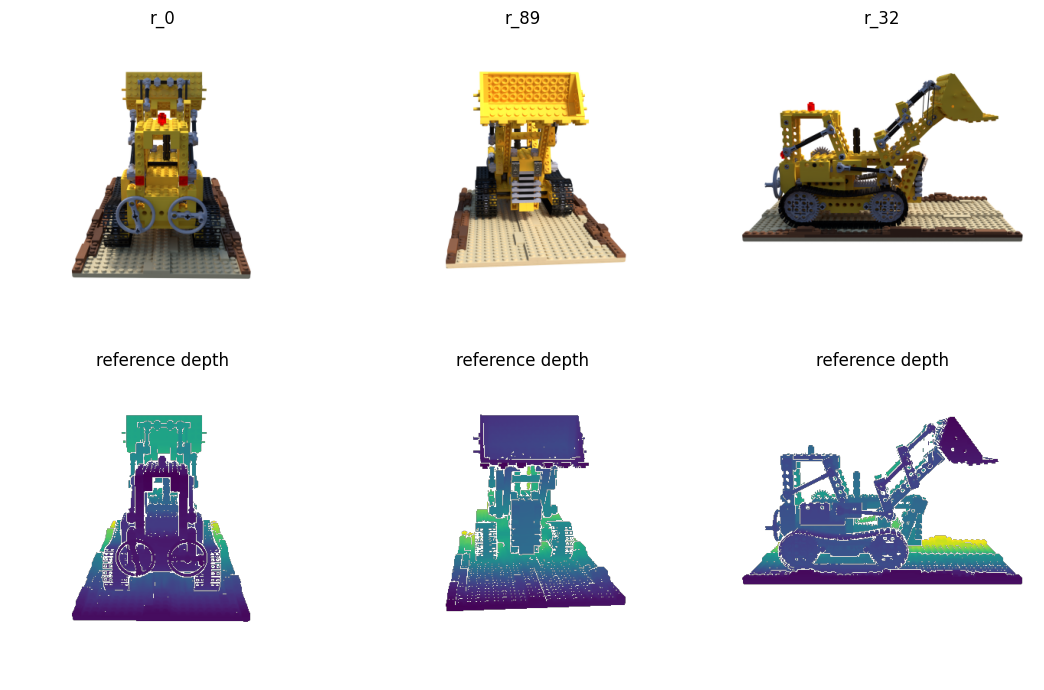

In [ ]:
#@title 6. Sanity check: the views, the reference depth, and SfM at 3 views
import numpy as np, matplotlib.pyplot as plt
from src.data import blender_poses, blender_sparse_split, load_blender_scene
from src.sfm import triangulate_views

SCENE = SCENES.split()[0]
ids = blender_sparse_split(3, blender_poses(scene=SCENE, split='train'))
vs = load_blender_scene(scene=SCENE, split='train', downscale=2, background=1.0, indices=ids).views
full = load_blender_scene(scene=SCENE, split='train', load_depth=False, background=1.0, indices=ids).views
pts, _, st = triangulate_views(full)
print(f'{SCENE}: views {ids} | image {vs[0].image.shape} | camera distance '
      f'{np.linalg.norm(vs[0].c2w[:3, 3]):.2f} | SfM points at 3 views: {st["n_points"]}')
fig, ax = plt.subplots(2, 3, figsize=(11, 7))
for j, v in enumerate(vs):
    ax[0, j].imshow(v.image); ax[0, j].set_title(v.name); ax[0, j].axis('off')
    if v.depth is not None:
        ax[1, j].imshow(np.where(v.depth > 0, v.depth, np.nan)); ax[1, j].set_title('reference depth')
    else:
        ax[1, j].text(0.5, 0.5, 'no depth yet -- run cell 5', ha='center')
    ax[1, j].axis('off')
plt.tight_layout()

### 7 · DTU SampleSet
Converts DTU's official SampleSet zip into the layout the loader reads: scans 1
and 6 at 400×300, the camera matrices, depth z-buffered from the structured-light
scan, and the files the official Chamfer evaluation needs. It reads straight from
the zip, and runs only when `PREPARE_DTU` is set, since only the `stage5_*`
stages use DTU.

In [ ]:
#@title 7. DTU SampleSet -> dtu/ (only needed for the stage5_* stages)
import os
PREPARE_DTU = False  #@param {type:'boolean'}
if PREPARE_DTU:
    # Build the command in Python: IPython skips ALL {} substitution on a
    # ! line that also holds a $NAME it cannot resolve as a Python variable.
    cmd = (f'python scripts/prepare_dtu.py --zip "{DATASETS}/DTU/SampleSet.zip" '
           f'--out "{os.environ["DATA_ROOT"]}"')
    !{cmd}
else:
    print('skipped (tick PREPARE_DTU before running a stage5_* stage)')

skipped (tick PREPARE_DTU before running a stage5_* stage)


### 8 · Training a stage
Launches one stage of `configs/sweep.yaml` through `scripts/run_sweep.py`. The
stages build on each other — the reproduction check, initialization against view
count, the λ sweep, the controlled corruptions, the real depth model, then DTU —
and each later stage is configured with the settings the earlier ones selected.
Before training, the stage's grid is expanded and the cells that provably cannot
produce an independent result are pruned; `--explain-pruning` prints the reason
for each.

Each run trains for 7,000 iterations (6,000 in the reproduction stage), about
1.5–2 minutes, then evaluates on the held-out views and is copied to Drive the
moment it finishes. `--resume` skips every run already on Drive, so a stage cut
off by a disconnect continues where it stopped. `SHARD` (`'0/2'`, `'1/2'`) splits
a stage between two sessions with no overlap, and `DRY_RUN` prints the grid
without training. The Depth Anything V2 stages download the model on first use.
All 257 runs of the study took 9.5 GPU hours.

In [ ]:
#@title 8. Launch a stage
STAGE = 'smoke'  #@param ["smoke", "stage0_repro", "stage1", "stage2_init_loss", "stage2_lambda", "stage3_noise", "stage3_affine", "stage3_perimage", "stage4_real", "stage5_dtu_base", "stage5_dtu_real", "stage5_dtu_oracle"]
SHARD = ''       #@param {type:'string'}
DRY_RUN = False  #@param {type:'boolean'}
extra = (f'--shard {SHARD} ' if SHARD else '') + ('--dry-run' if DRY_RUN else '')
!python scripts/run_sweep.py --sweep configs/sweep.yaml --stage {STAGE} --resume --explain-pruning {extra}

[smoke] 3 cells -> 3 to run, 0 pruned (0% saved)
[1/3] lego__init-random__n_views-3__depth_lambda-0p1__iterations-500
[blender/lego] init=random n_views=3 lambda=0.1
  initialized 100000 gaussians (random)
       0  loss 0.4512  rgb 0.4336  depth 0.1763  N=100000
     499  loss 0.0465  rgb 0.0409  depth 0.0562  N=100000
Setting up [LPIPS] perceptual loss: trunk [vgg], v[0.1], spatial [off]
/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.

### 9 · Results and checks
`scripts/evaluate.py` gathers every run's `metrics.json` from Drive into
`dl3dcv/results.csv`, leaving out runs trained before the opacity-reset fix and
runs no longer defined in `sweep.yaml`; failed runs are listed in
`results_failures.csv`. The cell then prints the number of runs per stage, the
reproduction check (vanilla 3DGS on the 8-view Blender split, against the published 22.23 dB), and
the divergence check (runs whose appearance and geometry moved in opposite directions, against
vanilla 3DGS and between neighbouring λ values).

In [ ]:
#@title 9. Collect every run and run the checks
import os, pandas as pd
from src import analysis as A
RESULTS = f'{PROJECT}/results.csv'
# Built in Python: IPython skips ALL {} substitution on a ! line that also
# holds a $NAME it cannot resolve as a Python variable.
cmd = f'python scripts/evaluate.py --runs "{os.environ["RUNS_MIRROR"]}" --out "{RESULTS}"'
!{cmd}
if not os.path.exists(RESULTS):
    raise SystemExit('no results.csv: no run has finished yet -- launch a stage in cell 8 first')
df = A.load_results(RESULTS)
print(df.groupby('stage').size().to_string(), '\n')

rep = df[df.stage == 'stage0_repro']
if len(rep):
    print(f'Reproduction check: 3DGS on Blender 8 views = {rep.psnr.mean():.2f} dB PSNR '
          f'/ {rep.ssim.mean():.3f} SSIM / {rep.lpips.mean():.3f} LPIPS over {len(rep)} scenes; '
          'published (DNGaussian, 3DGS row) 22.23 / 0.858 / 0.114\n')
if df['psnr_base'].isna().all():
    print('No vanilla-3DGS baseline yet (random init, no depth loss). The divergence check and the '
          'trade-off map compare against it -- run stage1.\n')
div = A.divergences(df)
print(f'Divergence check: {len(div)} run(s) moved appearance and geometry in '
      'opposite directions vs vanilla 3DGS')
display(div.head(15))
display(A.axis_divergences(df, 'depth_lambda').head(15))
fail = f'{PROJECT}/results_failures.csv'
if os.path.exists(fail):
    print('failed runs:'); display(pd.read_csv(fail)[['stage', 'run_id', 'error']])

wrote 3 run(s) to /content/drive/MyDrive/dl3dcv/results.csv
stage
smoke    3 

Divergence check: 0 run(s) moved appearance and geometry in opposite directions vs vanilla 3DGS


,stage,dataset,scene,n_views,init,depth_kind,depth_lambda,corruption,prior_absrel,psnr,geometry,d_psnr,d_geometry_rel,effect


""


### 10 · Figures
Draws five of the report's figures from `results.csv` — initialization by view
count, the 3-view λ sweep, both degradation curves and the trade-off map — and
saves each as PNG and PDF in `dl3dcv/figures`. A figure whose stage has not run
yet is replaced by a note naming that stage. The 9-view λ sweep is drawn by
`notebooks/analysis.ipynb`.

In [ ]:
#@title 10. Figures (also saved to Drive as PNG + PDF)
# A figure whose runs do not exist yet is skipped with the stage it needs,
# instead of being drawn as empty axes.
import os, matplotlib.pyplot as plt
FIG = f'{PROJECT}/figures'; os.makedirs(FIG, exist_ok=True)
figures = {'init_by_views': A.plot_init_by_views(df),
           'lambda_sweep_3v': A.plot_lambda_sweep(df, n_views=3),
           'degradation_absolute': A.plot_degradation(df, kind='absolute'),
           'degradation_ssi': A.plot_degradation(df, kind='ssi'),
           'tradeoff_map': A.plot_tradeoff_map(df)}
for name, fig in figures.items():
    if A.save(fig, f'{FIG}/{name}'):
        display(fig)
plt.close('all')
